In [15]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
sns.set_style('darkgrid')

In [16]:
df=pd.read_csv('profit_sales_dataset.csv')
df.head()

,order date (DateOrders),Order Id,Sales,Order Profit Per Order,Order Item Profit Ratio,Order Item Discount,Order Item Discount Rate,Category Name,Department Name,Product Name,Market,Order Country,Order Region,Customer Segment
0,1/31/2018 22:56,77202,327.75,91.250000,0.29,13.110000,0.04,Sporting Goods,Fitness,Smart watch,Pacific Asia,Indonesia,Southeast Asia,Consumer
1,1/13/2018 12:27,75939,327.75,-249.089996,-0.80,16.389999,0.05,Sporting Goods,Fitness,Smart watch,Pacific Asia,India,South Asia,Consumer
2,1/13/2018 12:06,75938,327.75,-247.779999,-0.80,18.030001,0.06,Sporting Goods,Fitness,Smart watch,Pacific Asia,India,South Asia,Consumer
3,1/13/2018 11:45,75937,327.75,22.860001,0.08,22.940001,0.07,Sporting Goods,Fitness,Smart watch,Pacific Asia,Australia,Oceania,Home Office
4,1/13/2018 11:24,75936,327.75,134.210007,0.45,29.500000,0.09,Sporting Goods,Fitness,Smart watch,Pacific Asia,Australia,Oceania,Corporate


In [17]:
df.describe()

,Order Id,Sales,Order Profit Per Order,Order Item Profit Ratio,Order Item Discount,Order Item Discount Rate
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,36221.894903,203.772096,21.974989,0.120647,20.664741,0.101668
std,21045.379569,132.273077,104.433526,0.466796,21.800901,0.070415
min,1.000000,9.990000,-4274.979980,-2.750000,0.000000,0.000000
25%,18057.000000,119.980003,7.000000,0.080000,5.400000,0.040000
50%,36140.000000,199.919998,31.520000,0.270000,14.000000,0.100000
75%,54144.000000,299.950012,64.800003,0.360000,29.990000,0.160000
max,77204.000000,1999.989990,911.799988,0.500000,500.000000,0.250000


In [18]:
total_sales = df['Sales'].sum()
total_profit = df['Order Profit Per Order'].sum()
profit_margin = (
    df['Order Profit Per Order'].sum()
    / df['Sales'].sum()
) * 100
AOV = df['Sales'].sum() / df['Order Id'].nunique()

print('Total Sales:', total_sales)
print('Total Profit:', total_profit)
print('Profit Margin %:', profit_margin)
print('Average Order Value:',AOV)

Total Sales: 36784735.01337984
Total Profit: 3966902.974050357
Profit Margin %: 10.78410099354382
Average Order Value: 559.4466330055335


Monthly Profit Trend

In [19]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

df['Year'] = df['order date (DateOrders)'].dt.year
df['Month'] = df['order date (DateOrders)'].dt.month_name()
df['Month_Num'] = df['order date (DateOrders)'].dt.month

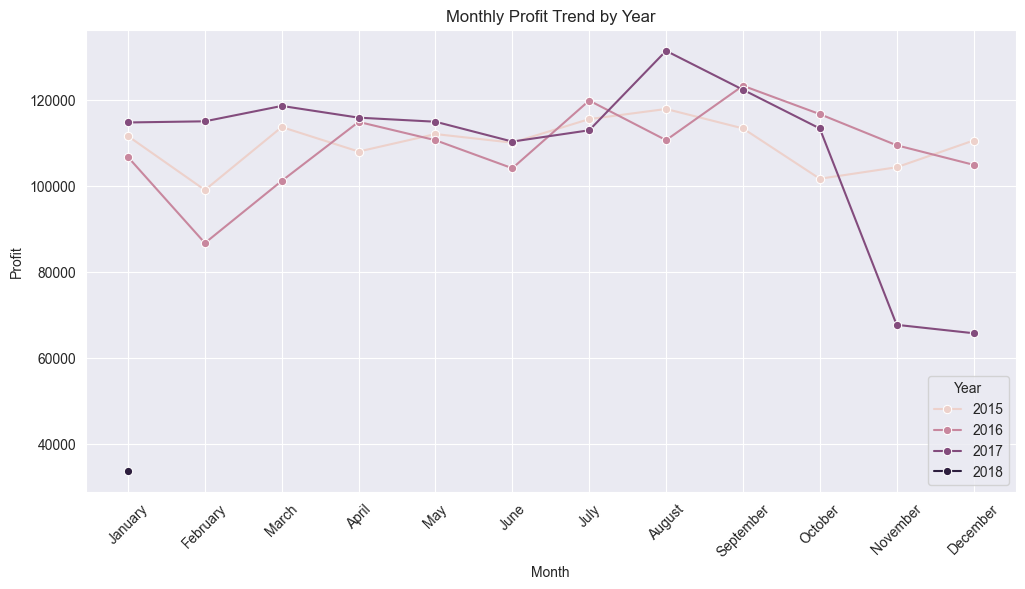

In [20]:
monthly_profit = (df.groupby(['Year', 'Month', 'Month_Num'])['Order Profit Per Order'].sum().reset_index())
monthly_profit = monthly_profit.sort_values(['Year', 'Month_Num'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_profit,x='Month',y='Order Profit Per Order',hue='Year',marker='o')
plt.title('Monthly Profit Trend by Year')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

Monthly Sales Trend


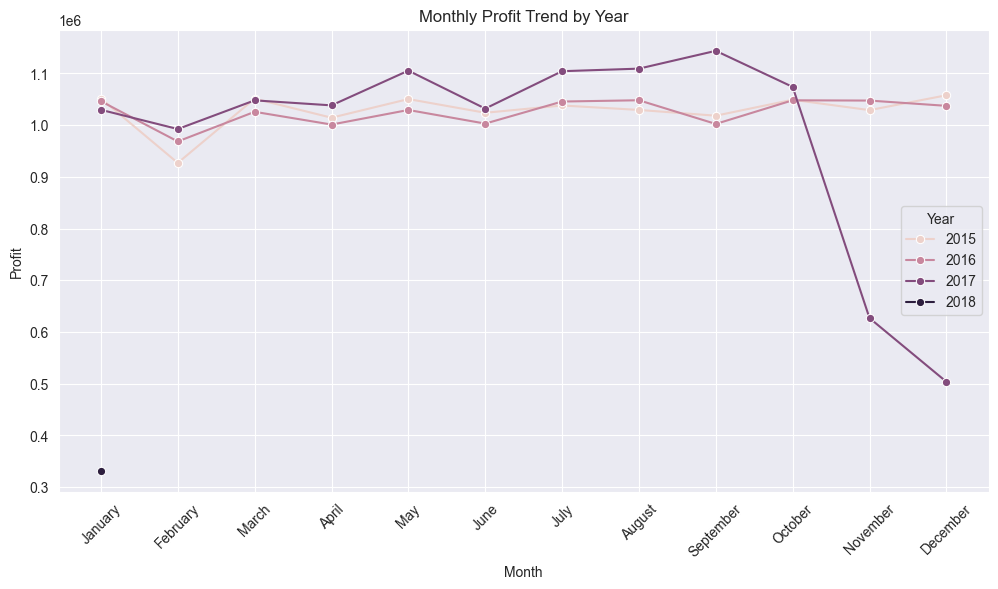

In [21]:
monthly_sales = (df.groupby(['Year', 'Month', 'Month_Num'])['Sales'].sum().reset_index())
monthly_sales = monthly_sales.sort_values(['Year', 'Month_Num'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales,x='Month',y='Sales',hue='Year',marker='o')
plt.title('Monthly Profit Trend by Year')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

Sales by Category

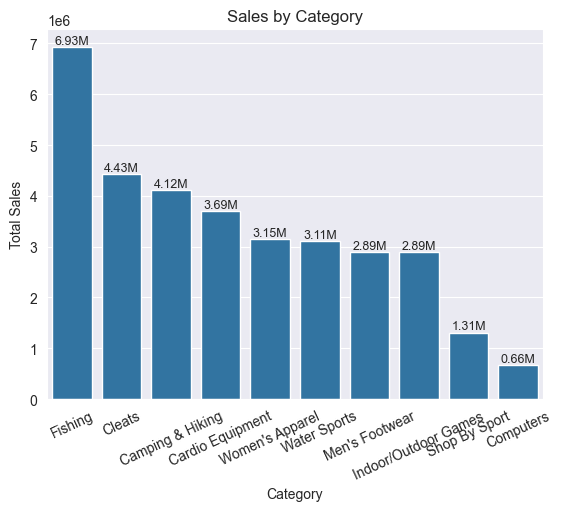

In [36]:
category_performance=df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(10)
ax=sns.barplot(category_performance)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1_000_000:.2f}M' for v in category_performance.values],
        fontsize=9
    )
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=25)
plt.show()

Profit by Category

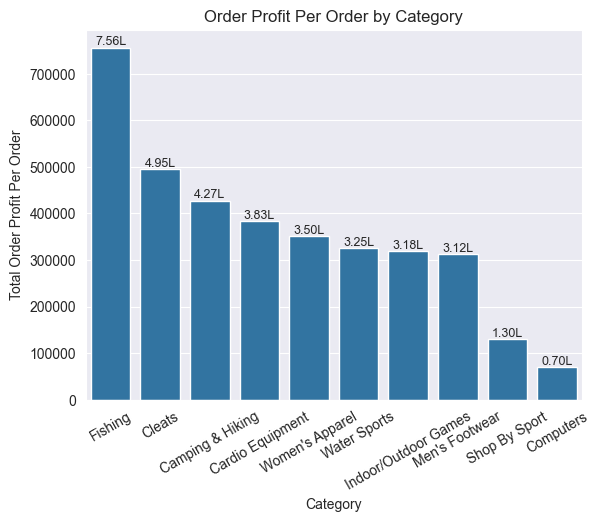

In [23]:
category_performance=df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10)
ax=sns.barplot(category_performance)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1_000_00:.2f}L' for v in category_performance.values],
        fontsize=9
    )
plt.title('Order Profit Per Order by Category')
plt.xlabel('Category')
plt.ylabel('Total Order Profit Per Order')
plt.xticks(rotation=30)
plt.show()

Sales vs Profit by Category

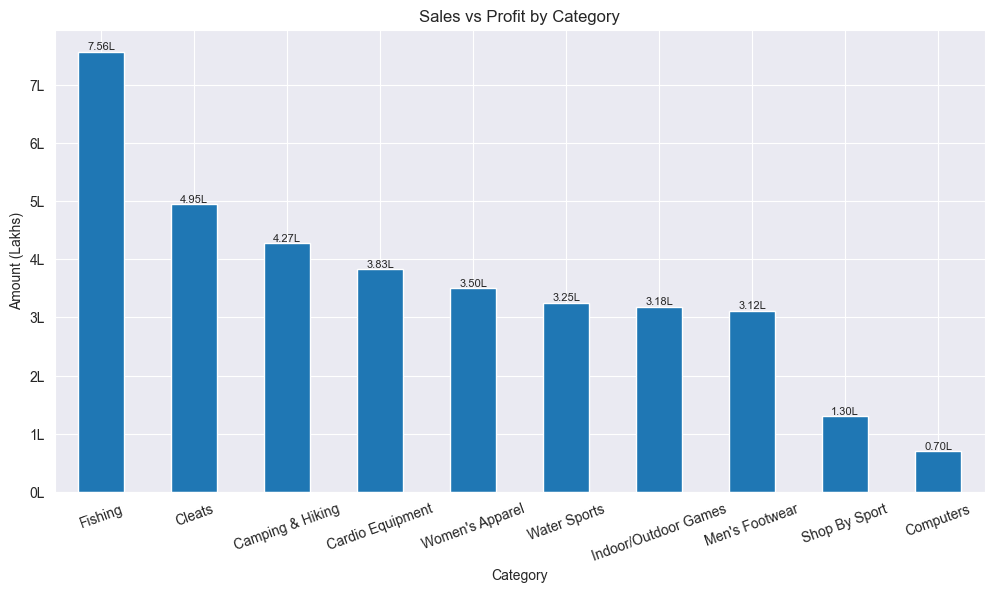

In [ ]:
import matplotlib.ticker as ticker
category_performance = (df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False)).head(10)
ax = category_performance.plot(x='Category Name',y=['Sales', 'Order Profit Per Order'],kind='bar',figsize=(12,6))

# Convert y-axis to Lakhs
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/100000:.0f}L'))

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/100000:.2f}L' for v in container.datavalues],
        fontsize=8
    )

plt.title('Sales vs Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount (Lakhs)')
plt.xticks(rotation=20)
plt.show()

Top 10 Products by Sales

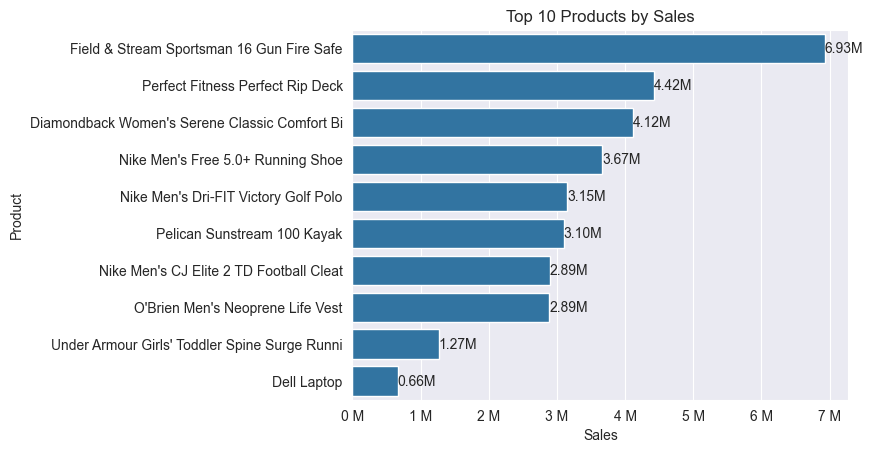

In [25]:
import matplotlib.ticker as ticker

product_performance=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
ax = sns.barplot(x=product_performance.values,y=product_performance.index)
# Convert x-axis to Lakhs
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000000:.0f} M'))

for container in ax.containers:
    ax.bar_label(container,labels=[f'{v/1_000_000:.2f}M' for v in product_performance.values])
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

Top 10 Products by Profit

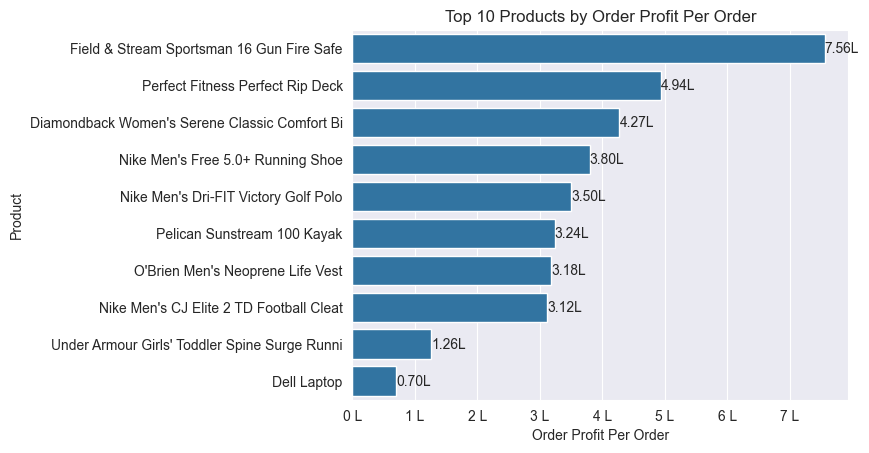

In [26]:
import matplotlib.ticker as ticker

product_performance=df.groupby('Product Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10)
ax = sns.barplot(x=product_performance.values,y=product_performance.index)
# Convert x-axis to Lakhs
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/100000:.0f} L'))

for container in ax.containers:
    ax.bar_label(container,labels=[f'{v/100000:.2f}L' for v in product_performance.values])
plt.title('Top 10 Products by Order Profit Per Order')
plt.xlabel('Order Profit Per Order')
plt.ylabel('Product')
plt.show()

Bottom 10 Products by Profit

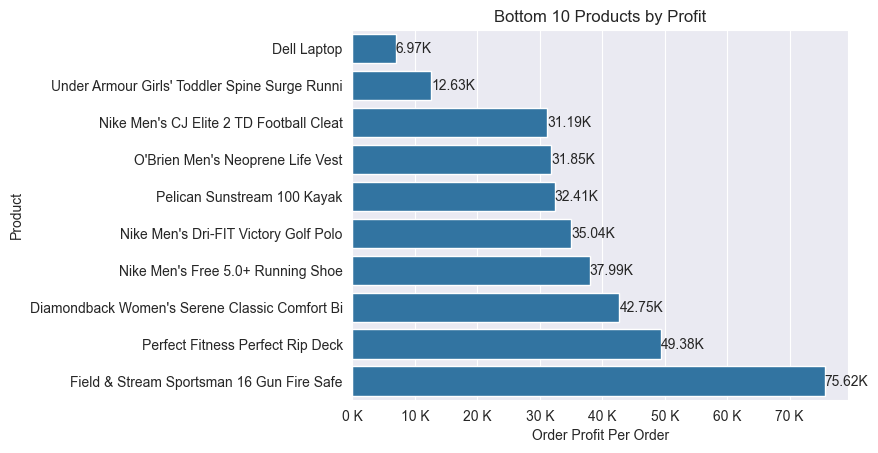

In [56]:
import matplotlib.ticker as ticker

product_performance=df.groupby('Product Name')['Order Profit Per Order'].sum().sort_values(ascending=True).tail(10)
ax = sns.barplot(x=product_performance.values,y=product_performance.index)
# Convert x-axis to Lakhs
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/10000:.0f} K'))

for container in ax.containers:
    ax.bar_label(container,labels=[f'{v/10000:.2f}K' for v in product_performance.values])
plt.title('Bottom 10 Products by Profit')
plt.xlabel('Order Profit Per Order')
plt.ylabel('Product')
plt.show()

Sales by Market

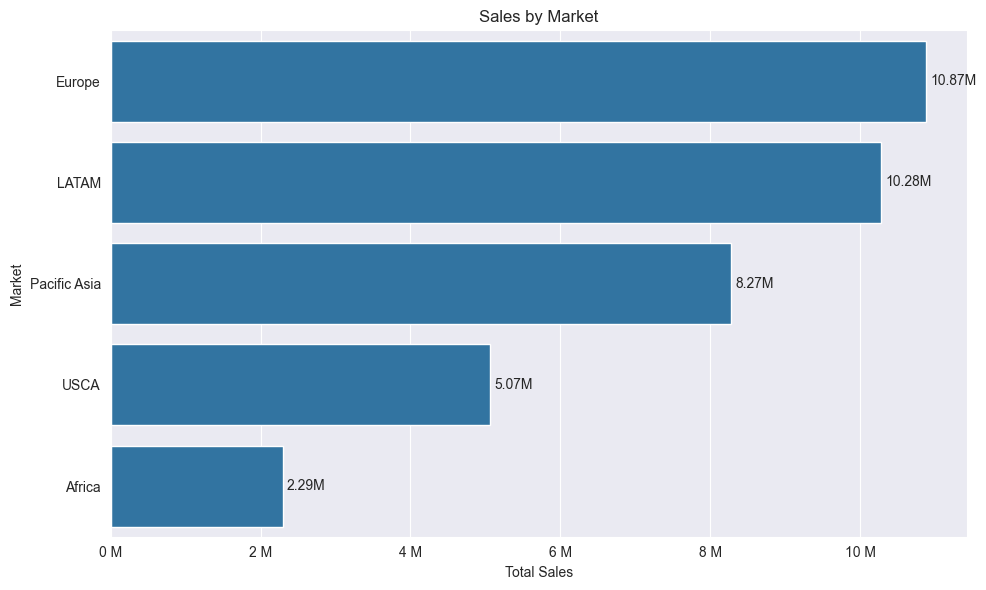

In [27]:
import matplotlib.ticker as ticker

market_sales = (df.groupby('Market')['Sales'].sum().sort_values(ascending=False))
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=market_sales.values,y=market_sales.index)
# Convert x-axis to Lakhs
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000000:.0f} M'))
for container in ax.containers:ax.bar_label(
        container,
        labels=[f'{v/1_000_000:.2f}M' for v in market_sales.values],
        padding=3
    )

plt.title('Sales by Market')
plt.xlabel('Total Sales')
plt.ylabel('Market')
plt.tight_layout()
plt.show()

Profit by Market

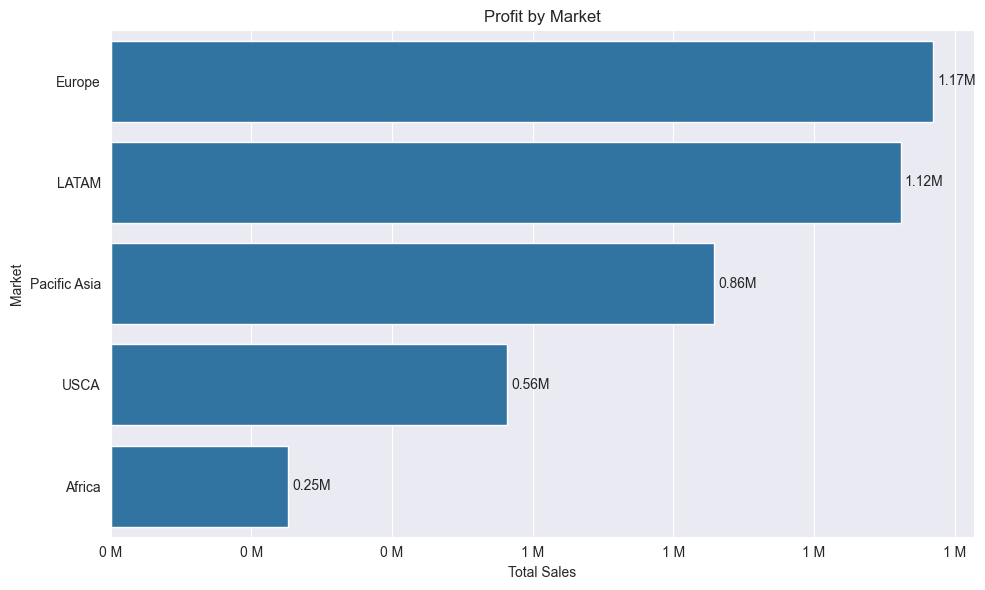

In [38]:
import matplotlib.ticker as ticker

market_sales = (df.groupby('Market')['Order Profit Per Order'].sum().sort_values(ascending=False))
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=market_sales.values,y=market_sales.index)
# Convert x-axis to Lakhs
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000000:.0f} M'))
for container in ax.containers:ax.bar_label(
        container,
        labels=[f'{v/1_000_000:.2f}M' for v in market_sales.values],
        padding=3
    )

plt.title('Profit by Market')
plt.xlabel('Total Sales')
plt.ylabel('Market')
plt.tight_layout()
plt.show()

Top Countries by Sales

Top Countries by Profit

Discount vs Profit

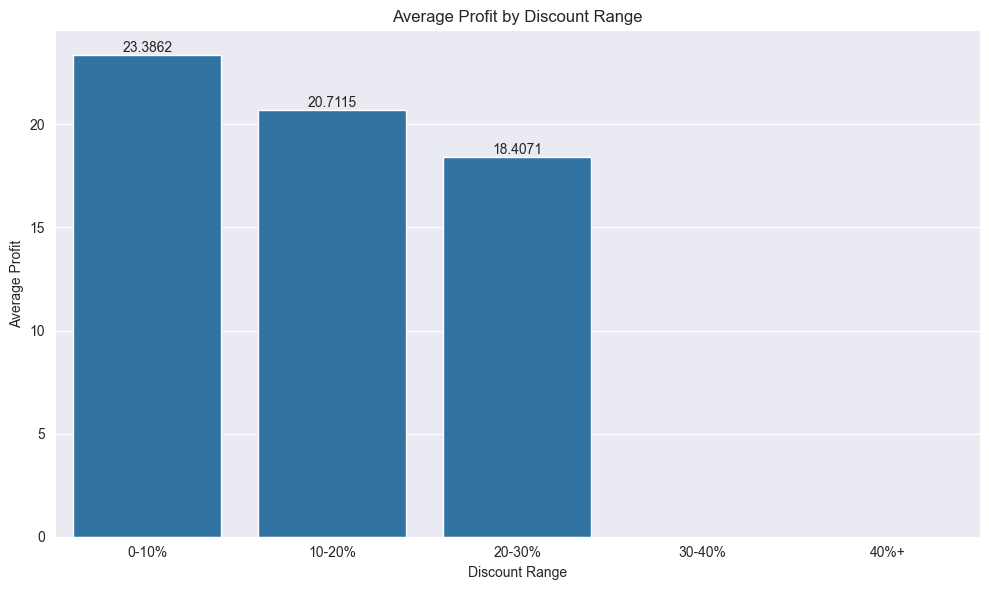

In [31]:
df['Discount Bucket'] = pd.cut(df['Order Item Discount Rate'],bins=[0, 0.1, 0.2, 0.3, 0.4, 1],
    labels=['0-10%','10-20%','20-30%','30-40%','40%+'])
discount_profit = (df.groupby('Discount Bucket', observed=False)['Order Profit Per Order'].mean().reset_index())

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=discount_profit,x='Discount Bucket',y='Order Profit Per Order')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Average Profit by Discount Range')
plt.ylabel('Average Profit')
plt.xlabel('Discount Range')
plt.tight_layout()
plt.show()

Profit Margin by Category

In [32]:
category_margin = (df.groupby('Category Name').agg({'Sales': 'sum','Order Profit Per Order': 'sum'}))
category_margin['Profit Margin %'] = (category_margin['Order Profit Per Order']/ category_margin['Sales']) * 100
category_margin = (category_margin.sort_values('Profit Margin %', ascending=False).reset_index())
category_margin.head()

,Category Name,Sales,Order Profit Per Order,Profit Margin %
0,Golf Bags & Carts,10369.390336,1810.069992,17.455896
1,Fitness Accessories,35601.440544,5258.390016,14.770161
2,Toys,6104.659979,900.710000,14.754466
3,Soccer,26477.049837,3901.949953,14.737102
4,Women's Clothing,140283.004745,19102.849930,13.617366


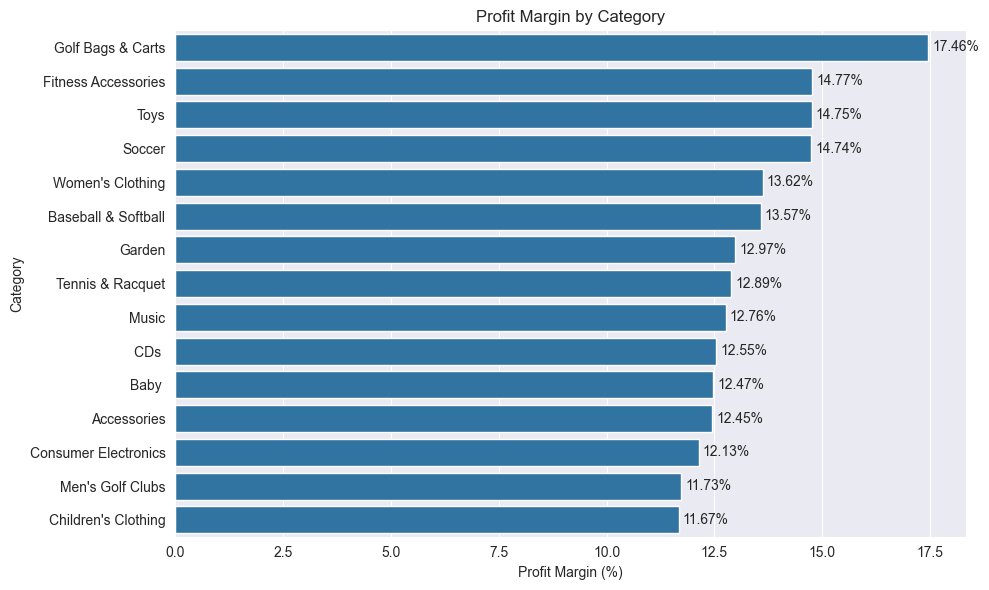

In [33]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=category_margin.head(15),x='Profit Margin %',y='Category Name')

for container in ax.containers:
    ax.bar_label(container,fmt='%.2f%%',padding=3)

plt.title('Profit Margin by Category')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()